In [1]:
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import scienceplots

In [2]:
df_tfd_base1 = pd.read_csv('../../cp/results_base1_tfd.csv')
df_tfd_base1 = df_tfd_base1.drop_duplicates(subset=['config','num_trains'])
df_tfd_base1 = df_tfd_base1.assign(planner='tfd', base='base1')

df_tfd_base2 = pd.read_csv('../../cp/results_base2_tfd.csv')
df_tfd_base2 = df_tfd_base2.drop_duplicates(subset=['config','num_trains'])
df_tfd_base2 = df_tfd_base2.assign(planner='tfd', base='base2')

df_tfd = pd.concat([df_tfd_base1, df_tfd_base2])

df_enhsp_base3 = pd.read_csv('../../cp/results_base3_enhsp.csv')
df_enhsp_base3 = df_enhsp_base3.drop_duplicates(subset=['config','num_trains'])
df_enhsp_base3 = df_enhsp_base3.assign(planner='enhsp', base='base3')

df_enhsp_base4 = pd.read_csv('../../cp/results_base4_enhsp.csv')
df_enhsp_base4 = df_enhsp_base4.drop_duplicates(subset=['config','num_trains'])
df_enhsp_base4 = df_enhsp_base4.assign(planner='enhsp', base='base4')

df_enhsp = pd.concat([df_enhsp_base3, df_enhsp_base4])

df_mff_base3 = pd.read_csv('../../cp/results_base3_metricff.csv')
df_mff_base3 = df_mff_base3.drop_duplicates(subset=['config','num_trains'])
df_mff_base3 = df_mff_base3.assign(planner='metricff', base='base3')

df_mff = df_mff_base3.copy()

df_nfd_base3 = pd.read_csv('../../cp/results_base3_nfd.csv')
df_nfd_base3 = df_nfd_base3.drop_duplicates(subset=['config','num_trains'])
df_nfd_base3 = df_nfd_base3.assign(planner='nfd', base='base3')

# df_nfd_base4 = pd.read_csv('../../cp/results_base4_nfd.csv')
# df_nfd_base4 = df_nfd_base4.drop_duplicates(subset=['config','num_trains'])
# df_nfd_base4 = df_nfd_base4.assign(planner='nfd', base='base4')

df_nfd = pd.concat([df_nfd_base3])#, df_nfd_base4])

df_base1 = df_tfd_base1.copy()
df_base2 = df_tfd_base2.copy()
df_base3 = pd.concat([df_enhsp_base3, df_mff_base3, df_nfd_base3])
df_base4 = pd.concat([df_enhsp_base4])#, df_nfd_base4])

df_temporal = pd.concat([df_base1, df_base2])
df_numeric = pd.concat([df_base3, df_base4])


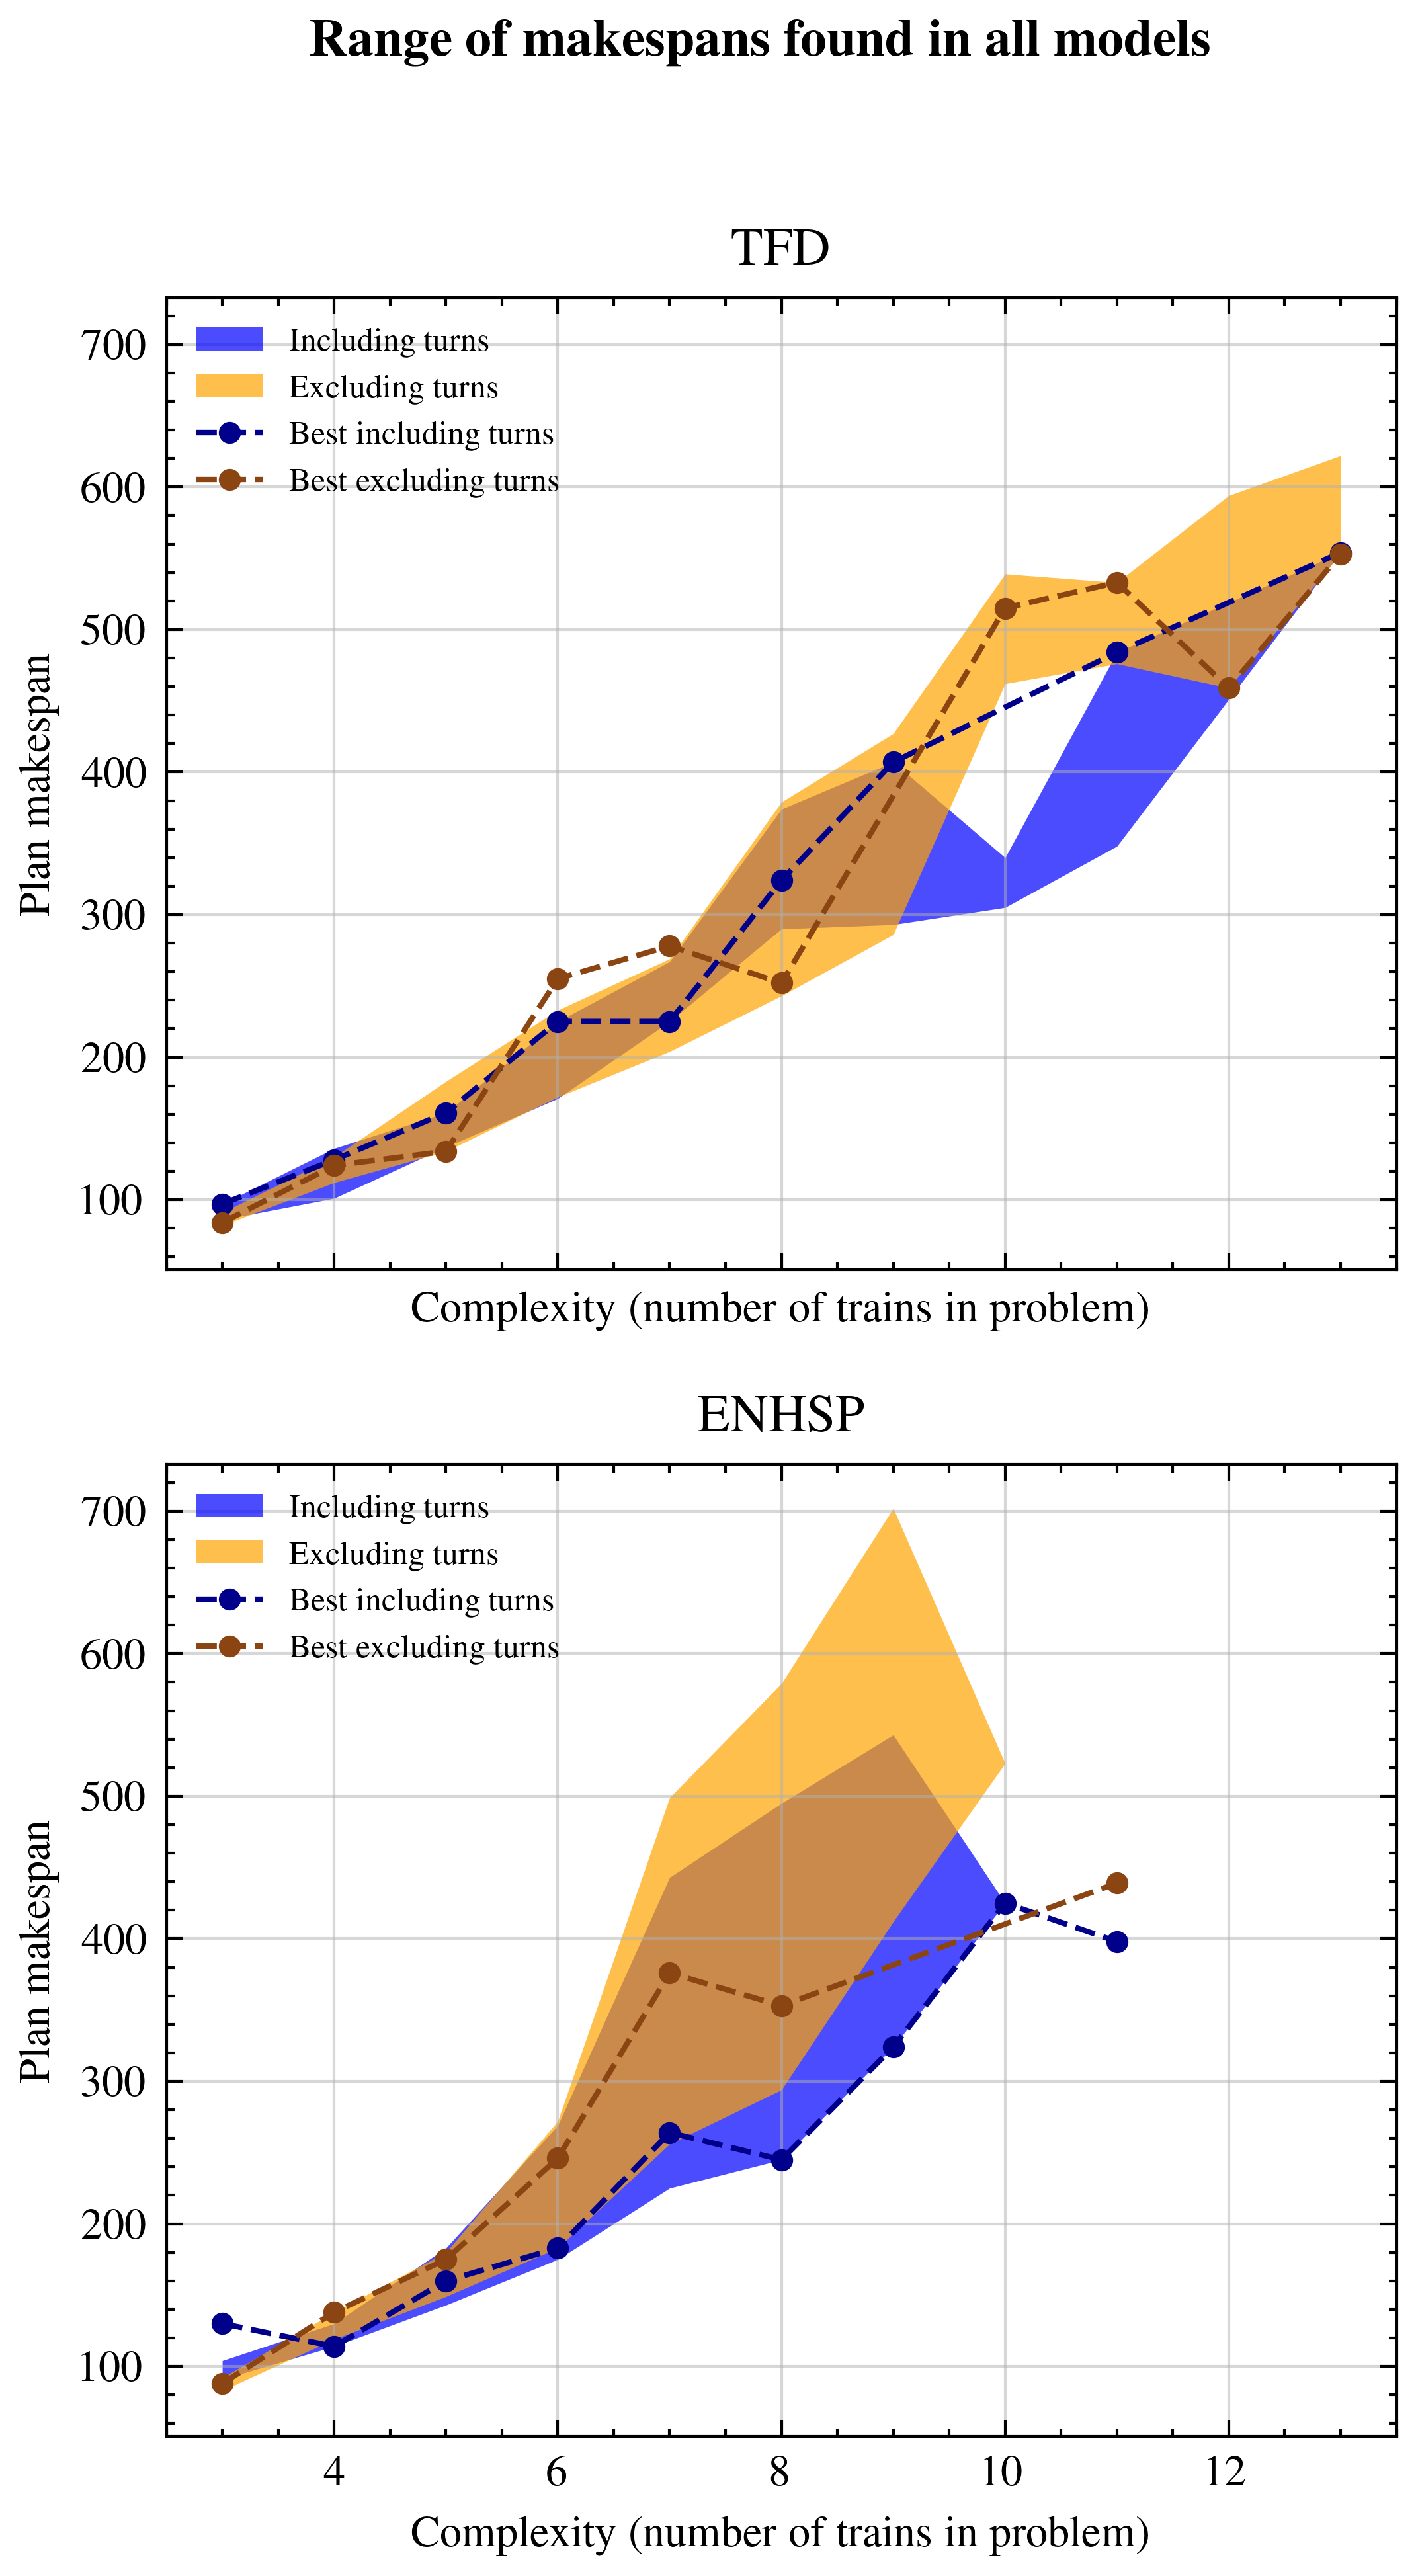

In [3]:
plt.style.use(['ieee', 'science'])


tfd_turn_x, tfd_turn_y1, tfd_turn_y2, tfd_noturn_x, tfd_noturn_y1, tfd_noturn_y2 = [], [], [], [], [], []
enhsp_turn_x, enhsp_turn_y1, enhsp_turn_y2, enhsp_noturn_x, enhsp_noturn_y1, enhsp_noturn_y2 = [], [], [], [], [], []

for num_t in range(3,20):
    df_tfd_turn = pd.concat([
            df_tfd.query(f'base=="base1" and config in (6,7,8,15,16,19) and num_trains=={num_t}'),
            df_tfd.query(f'base=="base2" and config in (5,6,7,11,14) and num_trains=={num_t}'),
        ])
    tfd_turn_makespans = sorted(df_tfd_turn['makespan_pp'])
    max_idx = min(len(tfd_turn_makespans)-1,6)
    if len(tfd_turn_makespans)> 0:
        tfd_turn_y1.append(tfd_turn_makespans[0])
        tfd_turn_y2.append(tfd_turn_makespans[max_idx])
        tfd_turn_x.append(num_t)

    df_tfd_noturn = pd.concat([
            df_tfd.query(f'base=="base1" and config not in (6,7,8,15,16,19) and num_trains=={num_t}'),
            df_tfd.query(f'base=="base2" and config not in (5,6,7,11,14) and num_trains=={num_t}'),
        ])
    tfd_noturn_makespans = sorted(df_tfd_noturn['makespan_pp'])
    max_idx = min(len(tfd_noturn_makespans)-1,6)
    if len(tfd_noturn_makespans)> 0:
        tfd_noturn_y1.append(tfd_noturn_makespans[0])
        tfd_noturn_y2.append(tfd_noturn_makespans[max_idx])
        tfd_noturn_x.append(num_t)





    df_enhsp_turn = pd.concat([
            df_enhsp.query(f'base=="base3" and config in (4,5,6,7,8,13,15,16,17,18) and num_trains=={num_t}'),
            df_enhsp.query(f'base=="base4" and config in (6,7,8,13,14) and num_trains=={num_t}'),
        ])
    enhsp_turn_makespans = sorted(df_enhsp_turn['makespan_pp'])
    max_idx = min(len(enhsp_turn_makespans)-1,6)
    if len(enhsp_turn_makespans)> 0:
        enhsp_turn_y1.append(enhsp_turn_makespans[0])
        enhsp_turn_y2.append(enhsp_turn_makespans[max_idx])
        enhsp_turn_x.append(num_t)

    df_enhsp_noturn = pd.concat([
            df_enhsp.query(f'base=="base3" and config not in (4,5,6,7,8,13,15,16,17,18) and num_trains=={num_t}'),
            df_enhsp.query(f'base=="base4" and config not in (6,7,8,13,14) and num_trains=={num_t}'),
        ])
    enhsp_noturn_makespans = sorted(df_enhsp_noturn['makespan_pp'])
    max_idx = min(len(enhsp_noturn_makespans)-1,6)
    if len(enhsp_noturn_makespans)> 0:
        enhsp_noturn_y1.append(enhsp_noturn_makespans[0])
        enhsp_noturn_y2.append(enhsp_noturn_makespans[max_idx])
        enhsp_noturn_x.append(num_t)
    
df_best_tfd_turn = df_tfd.query('planner=="tfd" and base=="base1" and config==16')
df_best_tfd_noturn = df_tfd.query('planner=="tfd" and base=="base1" and config==11')
df_best_enhsp_turn = df_enhsp.query('planner=="enhsp" and base=="base3" and config==6')
df_best_enhsp_noturn = df_enhsp.query('planner=="enhsp" and base=="base3" and config==1')


plt.style.use(['ieee', 'science'])

fig, ax = plt.subplots(2,1, figsize=(4,7), sharex=True, sharey=True)
fig.suptitle(r"""\textbf{Range of makespans found in all models}""")
ax[0].set_title('TFD')
ax[0].fill_between(tfd_turn_x, tfd_turn_y1, tfd_turn_y2, alpha=0.7, linewidth=0, label='Including turns', color='blue')
ax[0].fill_between(tfd_noturn_x, tfd_noturn_y1, tfd_noturn_y2, alpha=0.7, linewidth=0, label='Excluding turns', color='orange')
ax[0].plot(df_best_tfd_turn['num_trains'], df_best_tfd_turn['makespan_pp'], '.--', label='Best including turns', color='darkblue')
ax[0].plot(df_best_tfd_noturn['num_trains'], df_best_tfd_noturn['makespan_pp'], '.--', label='Best excluding turns', color='saddlebrown')
ax[0].grid(True, alpha=0.5)
ax[0].set_ylabel('Plan makespan')
ax[0].set_xlabel('Complexity (number of trains in problem)')
ax[0].legend(loc='upper left', fontsize=6)

ax[1].set_title('ENHSP')
ax[1].fill_between(enhsp_turn_x, enhsp_turn_y1, enhsp_turn_y2, alpha=0.7, linewidth=0, label='Including turns', color='blue')
ax[1].fill_between(enhsp_noturn_x, enhsp_noturn_y1, enhsp_noturn_y2, alpha=0.7, linewidth=0, label='Excluding turns', color='orange')
ax[1].plot(df_best_enhsp_turn['num_trains'], df_best_enhsp_turn['makespan_pp'], '.--', label='Best including turns', color='darkblue')
ax[1].plot(df_best_enhsp_noturn['num_trains'], df_best_enhsp_noturn['makespan_pp'], '.--', label='Best excluding turns', color='saddlebrown')
ax[1].grid(True, alpha=0.5)
ax[1].set_ylabel('Plan makespan')
ax[1].set_xlabel('Complexity (number of trains in problem)')
ax[1].legend(loc='upper left', fontsize=6)


# fig.tight_layout()
fig.savefig('turn_vs_noturn.png')
